## Introdução

O naufrágio do Titanic é um dos desastres marítimos mais conhecidos da história. 
O objetivo deste projeto é prever quais passageiros sobreviveram com base em características como idade, classe, gênero, entre outros, usando técnicas de Machine Learning.


## 📚 Importação das Bibliotecas

In [1]:
# Bibliotecas básicas
import pandas as pd
import numpy as np

# Visualização
import matplotlib.pyplot as plt
import seaborn as sns

# Modelagem
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# Ignorar warnings
import warnings
warnings.filterwarnings('ignore')


## 📂 Carregamento dos Dados

In [3]:
# Carregar os dados
train_data = pd.read_csv('train.csv')
test_data = pd.read_csv('test.csv')

# Ver as primeiras linhas
train_data.head()


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## 📊 Entendimento dos Dados

Vamos entender a estrutura dos dados disponíveis para o treinamento e previsão.

In [5]:
# Informações gerais
train_data.info()

# Estatísticas básicas
train_data.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


## 🧹 Tratamento de Dados


#### Verificando valores nulos

✅ Esse comando vai mostrar quantos valores faltam em cada coluna do train.csv.

In [9]:
# Verificar valores nulos
train_data.isnull().sum()


PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

#### Visualizando a porcentagem de valores ausentes

✅ Assim vamos saber quais colunas são mais "problemáticas"!

In [11]:
# Porcentagem de valores ausentes
missing_percentage = (train_data.isnull().sum() / len(train_data)) * 100
missing_percentage = missing_percentage[missing_percentage > 0].sort_values(ascending=False)

# Mostrar as colunas com valores ausentes
missing_percentage


Cabin       77.104377
Age         19.865320
Embarked     0.224467
dtype: float64

#### 📊 Resultado da análise de valores ausentes:

**Coluna**  **% de valores nulos**	**Observação**
- Cabin =          77.1%	            Muito dado faltando (quase todos)
- Age	=         19.9%	            Quantidade considerável de idades faltando
- mbarked =      0.22%	            Poucas entradas faltando


✅ As outras colunas como PassengerId, Survived, Pclass, Sex, Fare, etc, estão 100% completas!

### 📄 Código para tratar os dados

1. Excluir a coluna *Cabin* (quase vazia)

In [13]:
# Remover a coluna 'Cabin' por excesso de valores nulos
train_data = train_data.drop('Cabin', axis=1)
test_data = test_data.drop('Cabin', axis=1)


2. Preencher valores ausentes da coluna *Age* com a mediana

In [15]:
# Preencher valores ausentes de 'Age' com a mediana
train_data['Age'].fillna(train_data['Age'].median(), inplace=True)
test_data['Age'].fillna(test_data['Age'].median(), inplace=True)


3. Preencher valores ausentes da coluna *Embarked* com a moda.

In [17]:
# Preencher valores ausentes de 'Embarked' com a moda
train_data['Embarked'].fillna(train_data['Embarked'].mode()[0], inplace=True)


Vamos verificar novamente se ainda restaram valores ausentes:

In [19]:
# Verificar se ainda há valores nulos
train_data.isnull().sum()
test_data.isnull().sum()


PassengerId    0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           1
Embarked       0
dtype: int64

✅ No test_data ficou um único valor faltando em Fare!

Vamos preencher o valor faltante em Fare com a mediana da coluna Fare do test_data, assim como fizemos para Age.

In [21]:
# Preencher o valor ausente de 'Fare' no conjunto de teste
test_data['Fare'].fillna(test_data['Fare'].median(), inplace=True)


In [23]:
# Conferir se ainda tem valores nulos
test_data.isnull().sum()


PassengerId    0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

## 📊 Análise Exploratória dos Dados (EDA)

Nesta etapa, vamos:

✅ Entender as relações entre os dados

✅ Ver quem sobreviveu mais: Homens ou Mulheres? Crianças? Pessoas de 1ª classe?

✅ Gerar gráficos 

✅ Descobrir variáveis importantes para o modelo depois

#### 1. Análise de Sobreviventes (Homens vs Mulheres)

✅ Esse gráfico vai mostrar a relação entre sexo e sobrevivência.

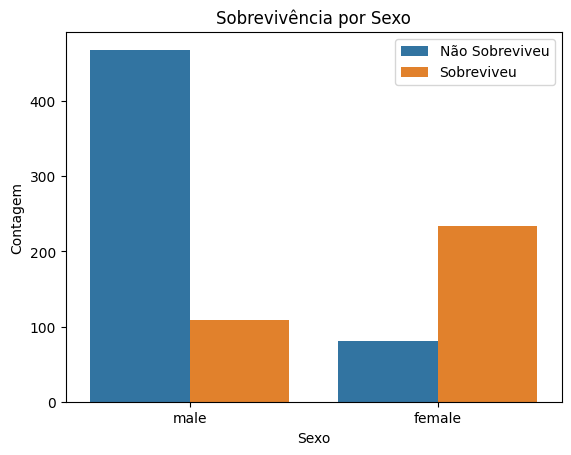

In [25]:
# Gráfico de sobrevivência por sexo
sns.countplot(data=train_data, x='Sex', hue='Survived')
plt.title('Sobrevivência por Sexo')
plt.xlabel('Sexo')
plt.ylabel('Contagem')
plt.legend(['Não Sobreviveu', 'Sobreviveu'])
plt.show()


#### 2. Análise por Classe (Pclass)

✅ Vai mostrar quem sobreviveu mais: 1ª, 2ª ou 3ª classe

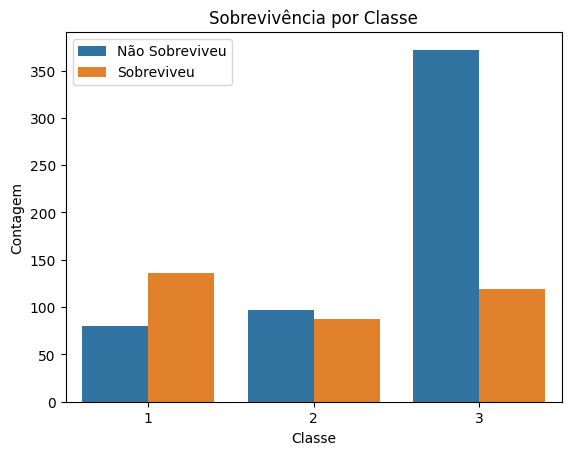

In [27]:
# Gráfico de sobrevivência por classe
sns.countplot(data=train_data, x='Pclass', hue='Survived')
plt.title('Sobrevivência por Classe')
plt.xlabel('Classe')
plt.ylabel('Contagem')
plt.legend(['Não Sobreviveu', 'Sobreviveu'])
plt.show()


#### 3. Análise da Idade (Distribuição)

✅ Entendimento como está distribuída a idade dos passageiros.

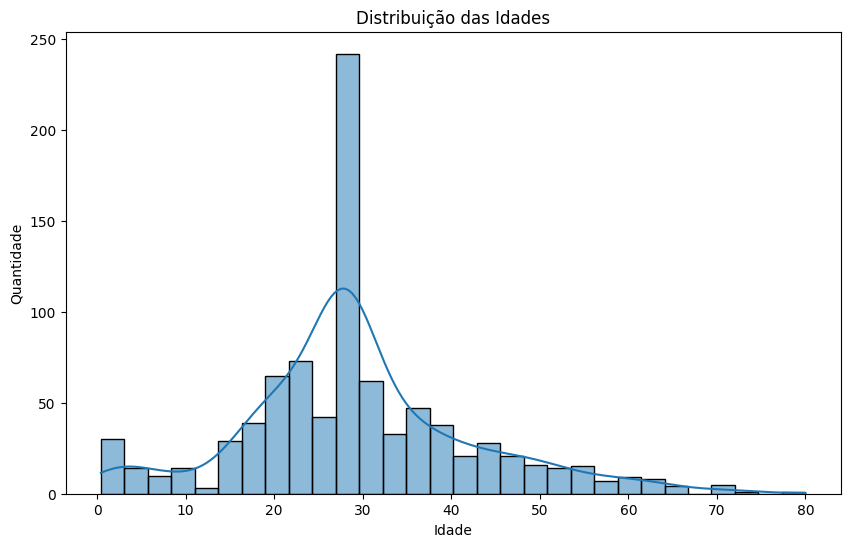

In [29]:
# Distribuição de Idade
plt.figure(figsize=(10,6))
sns.histplot(train_data['Age'], bins=30, kde=True)
plt.title('Distribuição das Idades')
plt.xlabel('Idade')
plt.ylabel('Quantidade')
plt.show()


### 📋 Agora vamos analisar o que os gráficos mostraram:

1️⃣ **Gráfico de Sobrevivência por Sexo (Sex)**

O gráfico mostra que mulheres sobreviveram muito mais do que homens.

Isso faz sentido: na época, mulheres e crianças foram prioridade nos botes salva-vidas.

✅ *Conclusão:* Sexo (Sex) é uma variável muito forte para prever sobrevivência!

2️⃣ **Gráfico de Sobrevivência por Classe (Pclass)**

Passageiros da 1ª Classe (Pclass = 1) sobreviveram muito mais do que os da 3ª Classe.

Pessoas da 3ª Classe tinham muito mais dificuldade para chegar aos botes.

✅ *Conclusão:* Classe (Pclass) é uma variável importante também!

3️⃣ **Gráfico de Distribuição de Idades (Age)**

Mostra que temos muitos adultos jovens no navio (entre 20-40 anos).

E também vemos que crianças pequenas estavam presentes.

✅ *Conclusão:* Idade (Age) também é relevante, especialmente crianças pequenas.

## 🛠️ Engenharia de Features

#### 📄 Código do Feature Engineering

#### 1. Codificando Sex e Embarked

✅ Agora Sex e Embarked serão números prontos para o modelo entender!

In [31]:
# Codificar 'Sex': male -> 0, female -> 1
train_data['Sex'] = train_data['Sex'].map({'male': 0, 'female': 1})
test_data['Sex'] = test_data['Sex'].map({'male': 0, 'female': 1})

# Codificar 'Embarked': S -> 0, C -> 1, Q -> 2
train_data['Embarked'] = train_data['Embarked'].map({'S': 0, 'C': 1, 'Q': 2})
test_data['Embarked'] = test_data['Embarked'].map({'S': 0, 'C': 1, 'Q': 2})


#### 2. Selecionar colunas importantes

Vamos trabalhar inicialmente com essas features:

- Pclass
- Sex
- Age
- SibSp
- Parch
- Fare
- Embarked

✅ E o alvo (o que queremos prever) é: *Survived*

In [33]:
# Features (variáveis independentes)
X = train_data[['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']]

# Target (variável dependente)
y = train_data['Survived']


#### 📋 Resumo da transformação até aqui:

Variável = O que foi feito

- Sex = Transformado para 0 e 1
- Embarked = Transformado para 0, 1 e 2
- Features = Selecionadas 7 colunas
  
Alvo: *Survived*

## 🤖 Criação dos Modelos

####🛠️ Separar dados de treino e teste (para validar o modelo)

Antes de treinar o modelo, precisamos dividir nossos dados (X, y) em:

**Conjunto - Descrição**

Treino (train) - Para o modelo aprender

Validação (test) - Para testar se o modelo aprendeu bem

✅ Vamos dividir 80% para treino e 20% para validação.

In [35]:
from sklearn.model_selection import train_test_split

# Separar dados: 80% treino / 20% validação
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# Mostrar tamanhos dos conjuntos
print(f'Tamanho do treino: {X_train.shape[0]}')
print(f'Tamanho da validação: {X_val.shape[0]}')


Tamanho do treino: 712
Tamanho da validação: 179


✅ Vamos usar Random Forest, que é um dos melhores para o Titanic!

📋 Agora vamos para a etapa mais legal.

#### 🤖 Treinar o primeiro modelo de Machine Learning: Random Forest Classifier

Vamos treinar o Random Forest com 712 exemplos, fazer previsões	com os 179 dados de validação, calcular a acurácia e avaliar a qualidade do modelo.

In [37]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# Criar o modelo Random Forest
model = RandomForestClassifier(random_state=42)

# Treinar o modelo com os dados de treino
model.fit(X_train, y_train)

# Fazer previsões nos dados de validação
y_pred = model.predict(X_val)

# Avaliar a acurácia
accuracy = accuracy_score(y_val, y_pred)
print(f'Acurácia do modelo Random Forest: {accuracy:.4f}')


Acurácia do modelo Random Forest: 0.8268


## 📝 Gerar a Previsão e o Arquivo de Submissão para o Kaggle

**Etapas**
- Fazer previsão em cima do test.csv
- Criação do CSV, PassengerId + Survived
- Salvar arquivo CSV
  
✅ Arquivo gerado: *submission.csv*

In [42]:
# Selecionar as mesmas features no dataset de teste
X_test = test_data[['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']]

# Fazer previsões no dataset de teste
y_test_pred = model.predict(X_test)

# Criar o DataFrame de submissão
submission = pd.DataFrame({
    'PassengerId': test_data['PassengerId'],
    'Survived': y_test_pred
})

# Salvar em CSV para enviar ao Kaggle
submission.to_csv('submission.csv', index=False)

print("Arquivo 'submission.csv' criado com sucesso!")


Arquivo 'submission.csv' criado com sucesso!


## 📈 Conclusão


Neste projeto, realizamos a análise e a construção de um modelo preditivo para o famoso desafio "Titanic: Machine Learning from Disaster" do Kaggle.

As principais etapas desenvolvidas foram:

- 📚 Entendimento dos dados e limpeza de valores ausentes.
- 📊 Análise Exploratória (EDA), identificando fatores importantes como sexo, classe e idade na sobrevivência.
- 🛠️ Engenharia de features, transformando variáveis categóricas em numéricas para modelagem.
- 🤖 Treinamento de um modelo de Random Forest Classifier, alcançando uma acurácia de **82.68%** nos dados de validação.
- 📝 Geração do arquivo `submission.csv` e submissão no Kaggle.

### 📋 Principais Insights:

- Mulheres tiveram maior taxa de sobrevivência do que homens.
- Passageiros da 1ª classe tiveram uma chance significativamente maior de sobrevivência.
- Crianças pequenas também apresentaram taxas de sobrevivência mais elevadas.

### 🚀 Próximos passos possíveis:

- Explorar modelos mais avançados (como XGBoost ou LightGBM).
- Realizar otimização de hiperparâmetros (Grid Search, Random Search).
- Criar novas variáveis (ex: "Tamanho da família" a partir de `SibSp` + `Parch`).
- Trabalhar mais a fundo no tratamento de outliers e na engenharia de features.

Este projeto foi uma excelente oportunidade para aplicar conceitos fundamentais de Data Science, Machine Learning e Análise de Dados em um problema clássico.

**Desenvolvido por Angelo Gatti Neto. 🙏🏻**
